## 1. Introducao

### 1.1 Contexto do trabalho
Este projeto trata da classificacao de reviews em portugues nas notas de 1 a 5.
A entrada tem `id`, `ASIN`, `title` e `text`; a saida e uma predicao de rating por linha do conjunto de teste.

### 1.2 Foco academico
A analise prioriza a evolucao do projeto por commits e as decisoes de engenharia de atributos.
A ideia central e mostrar **o que foi tentado, por que parecia correto, o que mudou nas metricas e o que aprendemos**.

### 1.3 Observacao metodologica
A melhor pontuacao historica veio de uma versao com IDF, mas ela nao podia ser usada pelas regras da disciplina.
Por isso, o desenvolvimento valido se concentrou em abordagens sem IDF com reforco de preprocessamento e features manuais.

In [31]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate

from preprocessing import load_train_test, prepare_datasets
from features import build_feature_frame, get_numeric_feature_columns
from model import build_training_pipeline

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TARGET_COLUMN = 'rating'

TRAIN_PATH = Path('train.csv')
TEST_PATH = Path('test.csv')
SAMPLE_SUBMISSION_PATH = Path('sample_submission.csv')
OUTPUT_SUBMISSION_PATH = Path('submission_final_consolidado.csv')

assert TRAIN_PATH.exists(), f'Arquivo nao encontrado: {TRAIN_PATH}'
assert TEST_PATH.exists(), f'Arquivo nao encontrado: {TEST_PATH}'
assert SAMPLE_SUBMISSION_PATH.exists(), f'Arquivo nao encontrado: {SAMPLE_SUBMISSION_PATH}'

print('Configuracao carregada com sucesso.')

Configuracao carregada com sucesso.


## 2. Entendimento do problema

### 2.1 Natureza da tarefa
- Problema: classificacao multiclasse (1 a 5).
- Dificuldade: classes intermediarias (2, 3 e 4) tendem a confundir, com reviews mistos (elogio + critica).
- Efeito de produto: alguns ASINs concentram padroes especificos de nota.

### 2.2 Evolucao por versao (resumo narrativo)
- Versao inicial com IDF teve melhor score historico, mas ficou fora da regra da disciplina.
- A trilha valida removeu IDF, reforcou preprocessamento e ampliou features manuais.
- Os refinos posteriores trouxeram ganhos marginais, com maior consistencia metodologica e melhor interpretacao tecnica.

## 3. Analise exploratoria (EDA)

A EDA foi reformulada para responder perguntas objetivas do problema:
- o dataset esta balanceado entre as classes?
- qual o perfil de tamanho dos textos por nota?
- existe concentracao forte em poucos produtos (`ASIN`)?

Essa leitura guia as decisoes de preprocessamento e o tipo de feature que vale a pena adicionar.

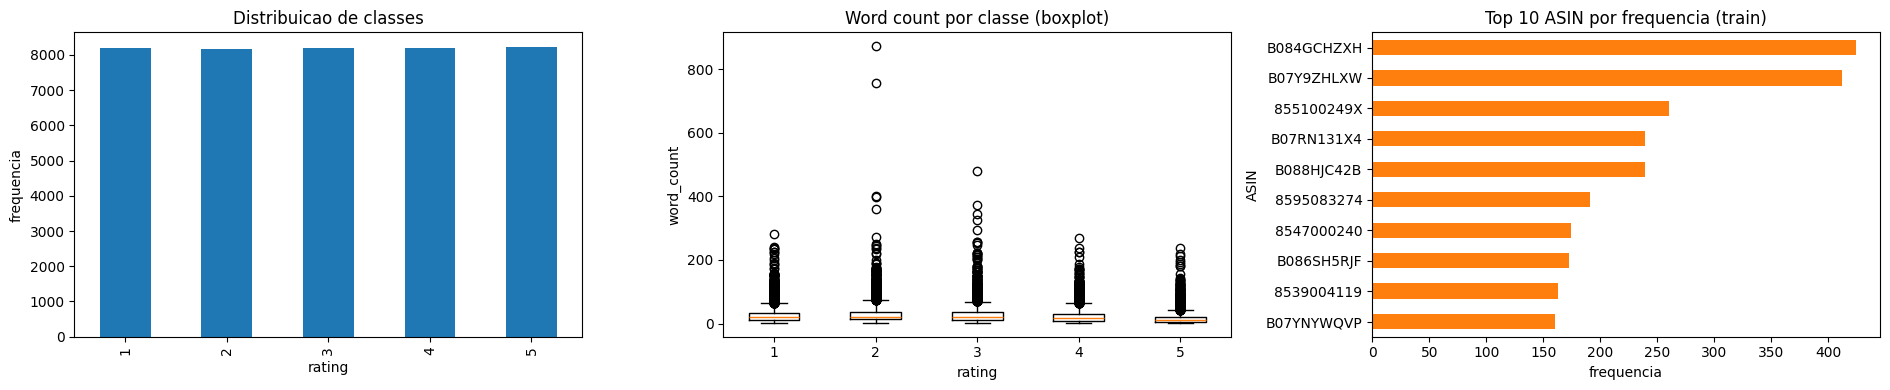

In [32]:
train_raw, test_raw = load_train_test(str(TRAIN_PATH), str(TEST_PATH), target_column=TARGET_COLUMN)

eda_df = train_raw.copy()
eda_df['title'] = eda_df['title'].fillna('').astype(str)
eda_df['text'] = eda_df['text'].fillna('').astype(str)
eda_df['combined_text'] = (eda_df['title'] + ' ' + eda_df['text']).str.strip()
eda_df['combined_text'] = eda_df['combined_text'].replace('', 'sem comentario')
eda_df['word_count'] = eda_df['combined_text'].str.split().str.len()

top_asin = eda_df['ASIN'].value_counts().head(10)

fig, axes = plt.subplots(1, 3, figsize=(19, 4))

eda_df[TARGET_COLUMN].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#1f77b4')
axes[0].set_title('Distribuicao de classes')
axes[0].set_xlabel('rating')
axes[0].set_ylabel('frequencia')

axes[1].boxplot(
    [eda_df.loc[eda_df[TARGET_COLUMN] == r, 'word_count'] for r in sorted(eda_df[TARGET_COLUMN].unique())],
    labels=sorted(eda_df[TARGET_COLUMN].unique()),
)
axes[1].set_title('Word count por classe (boxplot)')
axes[1].set_xlabel('rating')
axes[1].set_ylabel('word_count')

top_asin.sort_values().plot(kind='barh', ax=axes[2], color='#ff7f0e')
axes[2].set_title('Top 10 ASIN por frequencia (train)')
axes[2].set_xlabel('frequencia')

plt.tight_layout()
plt.show()

## 4. Pre-processamento

Fluxo aplicado:
- preenchimento de nulos em `title`, `text` e `ASIN`;
- criacao de `combined_text` (titulo + corpo);
- codificacao de produto (`asin_encoded`) e frequencia relativa (`asin_freq`).

A separacao treino/teste e respeitada para evitar vazamento de informacao.

Observacao: neste notebook final, o foco pratico de codigo foi mantido nas celulas de visualizacao grafica; a explicacao detalhada do preprocessamento fica descrita em texto.

## 5. Engenharia de atributos (features)

A evolucao das features seguiu uma logica de compensacao de sinal: quando o IDF foi removido por regra, precisavamos injetar no pipeline sinais que antes eram parcialmente capturados pela ponderacao TF-IDF.

### 5.1 Versao 1 - baseline inicial
- `combined_text` era o canal principal de texto para vetorizacao.
- O bloco numerico era enxuto, focado em comprimento (`word_count`, `char_count`), pontuacao (`exclamation_count`, `question_count`), enfase (`caps_word_count`), polaridade agregada (`sentiment_score`) e sinais de produto (`asin_encoded`).
- Leitura tecnica: um baseline simples, com maior dependencia da representacao automatica do texto.

### 5.2 Versao 2 - transicao sem IDF (`5635a03`)
- Restricao da disciplina: sem IDF, o vetor de contagem pura passa a ser mais sensivel a tokens muito frequentes.
- Decisao de engenharia:
  - reforcar preprocessamento textual (normalizacao leve, stopwords PT, limpeza de ruido);
  - ampliar o bloco numerico para recuperar sinal explicito.

Blocos de features adicionados/reforcados:
- Sentimento explicito:
  - `positive_word_count`, `negative_word_count`, `sentiment_ratio`, `mixed_sentiment_flag`.
  - Funcao: capturar dominancia de tom e casos mistos (elogio + critica), comuns em classes 2-4.
- Dominio e-commerce:
  - `defect_term_count/flag`, `price_term_count/flag`, `delivery_term_count/flag`, `negation_count`.
  - Funcao: representar causas concretas de nota (defeito, preco, entrega), pouco visiveis quando se olha so contagem de palavras.
- Estrutura de escrita:
  - `title_word_count`, `text_word_count`, `title_to_text_ratio`, `char_per_word`, taxas de pontuacao/caps.
  - Funcao: diferenciar reviews curtas/enfaticas de reviews longas/descritivas.
- Produto e contraste:
  - `asin_freq` e `antithesis_norm_count`.
  - Funcao: introduzir prior por item e sinal de ambivalencia discursiva ("mas", "porem"), relevante nas classes intermediarias.

### 5.3 Versao 3 - estado atual
- O `build_feature_frame` segue produzindo o mesmo conjunto rico de colunas da versao 2.
- No estado final, usamos apenas o modo `full`, com todas as features numericas disponiveis.

Leitura critica:
- O modo `full` melhora cobertura de sinais e interpretabilidade.
- Esse desenho privilegia explicacao tecnica completa dos fatores de decisao do modelo.

### 5.4 Consolidacao final das features

No estado final, os grupos de features podem ser entendidos assim:
- Comprimento e pontuacao: `word_count`, `char_count`, sinais de exclamacao/interrogacao e caixa alta.
- Sentimento: score agregado, contagens positiva/negativa, razao e flag de sentimento misto.
- Dominio e-commerce: defeito, preco, entrega e negacao.
- Estrutura titulo-corpo: tamanhos relativos e razao titulo/texto.
- Produto: `asin_encoded` e `asin_freq`.
- Contraste discursivo: `antithesis_norm_count`.

Essa organizacao melhora a explicacao funcional de cada bloco sem depender de tabelas em codigo.

### 5.5 Inventario completo das features finais (modo `full`)

Abaixo esta a lista completa das features numericas usadas na versao final, com o papel pratico de cada uma e por que foi adicionada.

**A) Comprimento, pontuacao e enfase**
- `word_count`: mede volume de texto; foi adicionada para separar reviews curtas e objetivas de reviews longas e detalhadas.
- `char_count`: comprimento bruto em caracteres; complementa `word_count` quando ha muita variacao de tamanho de palavra.
- `exclamation_count`: intensidade emocional direta ("!"); adicionada para captar enfase em elogios/reclamacoes.
- `question_count`: presenca de duvida/questionamento; adicionada para sinalizar linguagem de reclamacao ou incerteza.
- `caps_word_count`: contagem de palavras em caixa alta; adicionada para captar tom de enfase/frustracao.
- `exclamation_rate`: exclamacoes por palavra; adicionada para normalizar intensidade entre textos curtos e longos.
- `question_rate`: interrogacoes por palavra; adicionada para normalizar o efeito de perguntas.
- `caps_rate`: caixa alta por palavra; adicionada para evitar que so textos longos dominem a contagem bruta.
- `char_per_word`: media de caracteres por palavra; adicionada como proxy de estilo de escrita/ruido.

**B) Sentimento e polaridade**
- `sentiment_score`: saldo lexico positivo-negativo normalizado; adicionada como sinal global de polaridade.
- `positive_word_count`: contagem bruta de termos positivos; adicionada para reforcar evidencias de satisfacao.
- `negative_word_count`: contagem bruta de termos negativos; adicionada para reforcar evidencias de insatisfacao.
- `sentiment_ratio`: razao positivo/negativo com suavizacao; adicionada para representar dominancia de tom.
- `mixed_sentiment_flag`: flag de coexistencia de polos; adicionada para casos ambivalentes tipicos das classes 2-4.
- `sentiment_x_word_count`: interacao polaridade x tamanho; adicionada para diferenciar "pouco negativo" de "muito negativo".

**C) Dominio e-commerce (causa da nota)**
- `defect_term_count`: contagem de termos de defeito/falha; adicionada para sinal de notas baixas por problema funcional.
- `defect_flag`: indicador binario de defeito; adicionada para dar robustez quando a contagem e pequena.
- `price_term_count`: contagem de termos de preco/custo-beneficio; adicionada para captar julgamento economico.
- `price_flag`: indicador binario de preco; adicionada para estabilizar o sinal de tema economico.
- `delivery_term_count`: contagem de termos de entrega/prazo; adicionada para separar nota do produto de nota da logistica.
- `delivery_flag`: indicador binario de entrega; adicionada para reforcar esse fator quando aparece pontualmente.
- `negation_count`: contagem de negacoes (ex.: "nao"); adicionada para ajudar em inversao local de polaridade.

**D) Estrutura titulo-corpo**
- `title_word_count`: tamanho do titulo; adicionada para capturar padrao de resumo curto/objetivo.
- `text_word_count`: tamanho do corpo; adicionada para separar comentario rapido de relato detalhado.
- `title_to_text_ratio`: proporcao titulo/corpo; adicionada para medir equilibrio entre chamada e explicacao.

**E) Produto**
- `asin_encoded`: identidade do item codificada; adicionada para incorporar efeito especifico de produto.
- `asin_freq`: frequencia relativa do produto no treino; adicionada como prior de estabilidade por item.

**F) Contraste discursivo**
- `antithesis_norm_count`: densidade de conectivos adversativos ("mas", "porem", etc.); adicionada para captar mudanca de tom em reviews mistas.

**Leitura critica sobre excesso de features**
- Sim, ha indicio de que no fim tivemos **muitas features** para o ganho observado.
- Parte das variaveis e colinear/redundante (por exemplo, contagem bruta e taxa da mesma pista; contagens e flags do mesmo tema).
- Isso aumentou interpretabilidade e controle analitico, mas trouxe retorno decrescente em metrica.
- O resultado final sugere que o conjunto `full` foi util para explicacao tecnica, porem nao necessariamente o mais parcimonioso para generalizacao.
- Em termos de engenharia, o aprendizado foi: mais features nao implica automaticamente mais sinal novo; em varios casos, apenas redistribui o mesmo sinal com formatos diferentes.

## 6. Modelagem

### 6.1 Estrategia por versao (com fio condutor)
- V1 (invalida pela regra): `TfidfVectorizer` + classificadores tradicionais.
- V2 (valida): `CountVectorizer` sem IDF + preprocessamento reforcado + bloco numerico ampliado.
- V3 (estado final): mesmo paradigma linear, com arquitetura mais robusta e uso consolidado do modo `full`, com opcao de char n-grams.

### 6.2 Arquitetura final do pipeline
- Canal textual de palavras:
  - `CountVectorizer` em `combined_text` com `ngram_range=(1,2)`.
- Canal textual de caracteres (opcional):
  - `CountVectorizer(analyzer='char_wb', ngram_range=(3,5))`.
  - Funcao: capturar variacao ortografica, morfologia e ruido que escapam da tokenizacao por palavra.
- Bloco numerico:
  - features manuais escaladas com `StandardScaler(with_mean=False)`.
- Composicao:
  - `ColumnTransformer` concatena canais de palavra, caractere (quando ativo) e numerico.
- Classificador final:
  - `LinearSVC` (ajustes de estabilidade e regularizacao: `dual=False`, `max_iter`, `C`, `class_weight`).

### 6.3 Por que essa modelagem e coerente
- Respeita a restricao central (sem IDF).
- Mantem eficiencia em espaco esparso e alta dimensionalidade.
- Permite leitura de engenharia: sabemos quais sinais entram e para que servem.
- Suporta iteracao experimental sem trocar de familia de modelo.

### 6.4 Limite observado na pratica
- Mesmo com mais sinais, classes 2-4 continuam muito proximas semanticamente.
- Parte das features manuais e redundante com a propria representacao textual por contagem.
- Resultado: ganho incremental (refino de fronteira), sem salto de patamar.

## 7. Avaliacao

A avaliacao foi mantida com foco em aprendizado de projeto:
- o que mudou em cada versao relevante;
- por que cada mudanca parecia promissora;
- o que de fato aconteceu com as metricas;
- por que a melhoria final foi limitada.

### 7.1 Resultado consolidado
- V1 com IDF (invalida para a regra): melhor historico (~0.52).
- Trilha valida sem IDF: estabilizacao na faixa ~0.46.
- Melhor refino sem IDF reportado no historico: ~0.4673.
- Holdout documentado no estado atual (SVM linear, configuracao enxuta):
  - `f1_macro` ~ 0.462
  - `accuracy` ~ 0.466

### 7.2 Sintese critica da estagnacao
- Restricao metodologica real: a versao de maior score precisou ser descartada.
- Compensacao incompleta: features manuais melhoram explicacao, mas nao substituem totalmente o efeito estatistico do IDF.
- Sobreposicao entre classes: notas 2, 3 e 4 compartilham linguagem muito parecida.
- Retorno decrescente: mais engenharia de atributos trouxe principalmente interpretabilidade, com ganho modesto de metrica.

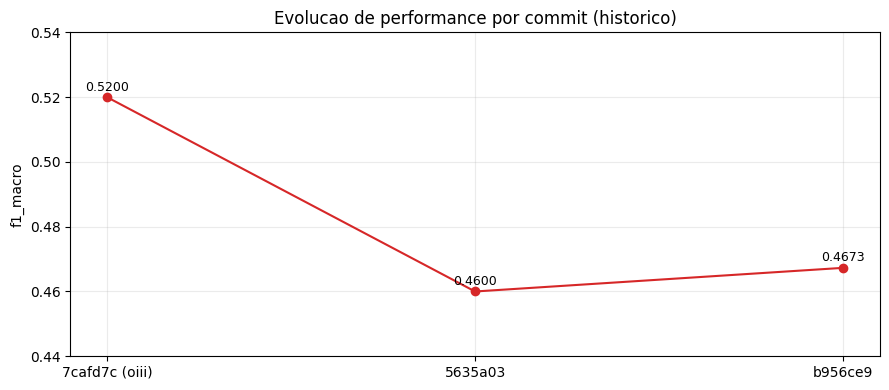

In [33]:
historical_rows = [
    {
        'Commit': '7cafd7c (oiii)',
        'Versao': 'V1 (invalida pela regra)',
        'Modelo': 'TF-IDF + baseline inicial',
        'f1_macro': 0.52,
        'Fonte': 'Historico informado pelo time (IDF proibido)'
    },
    {
        'Commit': '5635a03',
        'Versao': 'V2',
        'Modelo': 'Count + melhorias de preprocess/features',
        'f1_macro': 0.46,
        'Fonte': 'Mensagem de commit e documentacao interna'
    },
    {
        'Commit': 'b956ce9',
        'Versao': 'V2 refinada',
        'Modelo': 'Diff approach sem IDF',
        'f1_macro': 0.4673,
        'Fonte': 'Mensagem de commit e documentacao interna'
    },
]

history_df = pd.DataFrame(historical_rows)

plt.figure(figsize=(9, 4))
plt.plot(history_df['Commit'], history_df['f1_macro'], marker='o', color='#d62728')
for i, row in history_df.iterrows():
    plt.text(i, row['f1_macro'] + 0.002, f"{row['f1_macro']:.4f}", ha='center', fontsize=9)
plt.title('Evolucao de performance por commit (historico)')
plt.ylabel('f1_macro')
plt.ylim(min(history_df['f1_macro']) - 0.02, max(history_df['f1_macro']) + 0.02)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 8. Conclusao

### 8.1 O que aprendemos com a evolucao
- O melhor resultado historico veio do uso de IDF, que melhora relevancia de termos, mas essa linha foi descartada por regra.
- Ao remover IDF, o time fez a decisao correta metodologicamente: reforcou preprocessamento e adicionou features explicativas.
- As features novas foram escolhidas com logica consistente (sentimento, dominio, contraste, produto), e foram corretamente aplicadas no pipeline.

### 8.2 Por que a precisao praticamente nao aumentou
- As novas features agregaram **interpretabilidade** e **controle experimental**, mas pouco sinal realmente novo para separar classes parecidas.
- Parte das features e redundante com o que ja estava no texto vetorizado por contagem.
- O problema de classes intermediarias continua dificil; por isso o ganho final ficou marginal.
- Em resumo: o projeto melhorou como engenharia e narrativa tecnica, mas nao mudou de patamar de desempenho.

### 8.3 Justificativa final
A versao final e tecnicamente justificavel porque respeita as restricoes, organiza melhor o pipeline e explica claramente as decisoes de feature engineering. Mesmo sem salto de precisao, ela representa a melhor versao valida e apresentavel do desenvolvimento.

## 9. Anexo executavel - codigo original do projeto

Esta secao replica o codigo original em celulas de notebook para facilitar revisao e execucao pelo professor.

Ordem sugerida de execucao:
1. Celula de preprocessamento
2. Celula de features
3. Celula de modelagem e utilitarios
4. Celula de execucao fim a fim

In [ ]:
# Bloco 9.1 - Preprocessamento (codigo original)
from __future__ import annotations

import re
from typing import Tuple

import pandas as pd
from sklearn.preprocessing import LabelEncoder

BASE_REQUIRED_COLUMNS = ["id", "ASIN", "title", "text"]
TEST_REQUIRED_COLUMNS = ["id", "ASIN", "title", "text"]

PORTUGUESE_STOPWORDS = {
    "a", "o", "as", "os", "um", "uma", "uns", "umas",
    "de", "da", "do", "das", "dos",
    "em", "no", "na", "nos", "nas",
    "para", "por", "com", "sem",
    "e", "ou", "que", "como", "muito", "muita", "muitos", "muitas",
    "se", "isso", "essa", "esse", "esses", "essas", "isto", "aquilo",
    "foi", "ser", "ter", "sou", "era", "sao", "são", "é",
    "ao", "aos", "à", "às", "seu", "sua", "seus", "suas",
    "meu", "minha", "meus", "minhas", "você", "vocês", "eu", "nós",
}


def normalize_text_for_vectorizer(text: str) -> str:
    normalized = str(text).lower()
    normalized = re.sub(r"http\S+|www\S+", " ", normalized)
    normalized = re.sub(r"\s+", " ", normalized).strip()
    return normalized


def get_portuguese_stopwords() -> list[str]:
    antithesis_single_terms = {
        term.lower()
        for term in ANTITHESIS_TERMS
        if len(term.split()) == 1
    }
    filtered_stopwords = PORTUGUESE_STOPWORDS - antithesis_single_terms
    return sorted(filtered_stopwords)


def _validate_columns(df: pd.DataFrame, required_columns: list[str], file_label: str) -> None:
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise ValueError(f"{file_label} sem colunas obrigatorias: {missing}")


def load_train_test(train_path: str, test_path: str, target_column: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    train_required_columns = BASE_REQUIRED_COLUMNS + [target_column]
    _validate_columns(train_df, train_required_columns, "train file")
    _validate_columns(test_df, TEST_REQUIRED_COLUMNS, "test.csv")

    return train_df, test_df


def clean_text_fields(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = df.copy()

    cleaned["title"] = cleaned["title"].fillna("").astype(str).str.strip()
    cleaned["text"] = cleaned["text"].fillna("").astype(str).str.strip()
    cleaned["ASIN"] = cleaned["ASIN"].fillna("UNKNOWN").astype(str).str.strip()

    cleaned["title"] = cleaned["title"].replace(".", "", regex=False)

    cleaned["combined_text"] = (cleaned["title"] + " " + cleaned["text"]).str.strip()
    cleaned["combined_text"] = cleaned["combined_text"].replace("", "sem comentario")

    return cleaned


def fit_asin_encoder(train_df: pd.DataFrame) -> LabelEncoder:
    encoder = LabelEncoder()
    encoder.fit(train_df["ASIN"].astype(str))
    return encoder


def transform_asin(df: pd.DataFrame, encoder: LabelEncoder) -> pd.Series:
    asin_to_int = {asin: idx for idx, asin in enumerate(encoder.classes_)}
    return df["ASIN"].map(asin_to_int).fillna(-1).astype(int)


def fit_asin_frequency(train_df: pd.DataFrame) -> pd.Series:
    return train_df["ASIN"].value_counts(normalize=True)


def transform_asin_frequency(df: pd.DataFrame, asin_frequency: pd.Series) -> pd.Series:
    return df["ASIN"].map(asin_frequency).fillna(0.0).astype(float)


def prepare_datasets(train_df: pd.DataFrame, test_df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, LabelEncoder]:
    train_clean = clean_text_fields(train_df)
    test_clean = clean_text_fields(test_df)

    asin_encoder = fit_asin_encoder(train_clean)
    asin_frequency = fit_asin_frequency(train_clean)

    train_clean["asin_encoded"] = transform_asin(train_clean, asin_encoder)
    test_clean["asin_encoded"] = transform_asin(test_clean, asin_encoder)
    train_clean["asin_freq"] = transform_asin_frequency(train_clean, asin_frequency)
    test_clean["asin_freq"] = transform_asin_frequency(test_clean, asin_frequency)

    return train_clean, test_clean, asin_encoder

In [ ]:
# Bloco 9.2 - Features (codigo original)
import re

POSITIVE_WORDS = {
    "bom", "boa", "bons", "boas", "otimo", "otima", "ótimo", "ótima", "excelente",
    "recomendo", "gostei", "adorei", "perfeito", "perfeita", "maravilhoso", "maravilhosa",
    "amei", "satisfeito", "satisfeita", "qualidade", "beneficio", "benefício", "aprovado",
    "funciona", "funcionou", "duravel", "durável",
}

NEGATIVE_WORDS = {
    "ruim", "péssimo", "pessimo", "péssima", "pessima", "horrível", "horrivel", "decepcao",
    "decepção", "decepcionante", "nao", "não", "nunca", "absurdo", "rasgado", "quebrou",
    "defeito", "defeituoso", "fraco", "travando", "frustrante", "caro", "lento", "atraso",
    "demorou",
}

WORD_PATTERN = re.compile(r"\b\w+\b", flags=re.UNICODE)
TOKEN_PATTERN = re.compile(r"[A-Za-zÀ-ÿ]+", flags=re.UNICODE)
CAPS_PATTERN = re.compile(r"\b[A-ZÀ-Ý]{2,}\b", flags=re.UNICODE)

ANTITHESIS_TERMS = [
    "mas", "porém", "porem", "entretanto", "contudo", "todavia",
    "apesar de", "não obstante", "nao obstante",
]

DEFECT_TERMS = [
    "quebrou", "rasgado", "defeito", "defeituoso", "faltando", "faltou", "nao funciona",
    "não funciona", "nao lig", "não lig", "travando", "deteriorado",
]

PRICE_TERMS = [
    "preco", "preço", "caro", "barato", "custo", "valor", "abusivo", "custo beneficio",
    "custo-beneficio", "custo-benefício", "nao vale", "não vale",
]

DELIVERY_TERMS = [
    "entrega", "entregue", "chegou", "prazo", "rastre", "postagem", "atras", "atraso", "demorou",
]

NEGATION_TERMS = {"nao", "não", "nunca", "nem", "jamais"}


def _word_count(text: str) -> int:
    return len(WORD_PATTERN.findall(text))


def _char_count(text: str) -> int:
    return len(text)


def _exclamation_count(text: str) -> int:
    return text.count("!")


def _question_count(text: str) -> int:
    return text.count("?")


def _caps_word_count(text: str) -> int:
    return len(CAPS_PATTERN.findall(text))


def _tokenize_lower(text: str) -> list[str]:
    return [token.lower() for token in TOKEN_PATTERN.findall(text)]


def _count_lexicon_hits(tokens: list[str], lexicon: set[str]) -> int:
    return sum(1 for token in tokens if token in lexicon)


def _count_pattern_occurrences(lowered: str, terms: list[str]) -> int:
    total = 0
    for term in terms:
        if " " in term:
            total += lowered.count(term)
        else:
            total += len(re.findall(rf"\\b{re.escape(term)}", lowered))
    return total


def _sentiment_score(text: str) -> float:
    tokens = _tokenize_lower(text)
    if not tokens:
        return 0.0

    positive_hits = _count_lexicon_hits(tokens, POSITIVE_WORDS)
    negative_hits = _count_lexicon_hits(tokens, NEGATIVE_WORDS)
    return (positive_hits - negative_hits) / max(len(tokens), 1)


def _antithesis_norm_count(text: str, word_count: int) -> float:
    lowered = text.lower()
    occurrences = _count_pattern_occurrences(lowered, ANTITHESIS_TERMS)
    return occurrences / max(word_count, 1)


def build_feature_frame(df: pd.DataFrame) -> pd.DataFrame:
    features = pd.DataFrame(index=df.index)

    text_series = df["combined_text"].fillna("").astype(str)
    title_series = df.get("title", pd.Series("", index=df.index)).fillna("").astype(str)
    body_series = df.get("text", pd.Series("", index=df.index)).fillna("").astype(str)
    lowered_series = text_series.str.lower()
    token_series = text_series.apply(_tokenize_lower)

    features["combined_text"] = text_series

    features["word_count"] = text_series.apply(_word_count)
    features["char_count"] = text_series.apply(_char_count)
    features["exclamation_count"] = text_series.apply(_exclamation_count)
    features["question_count"] = text_series.apply(_question_count)
    features["caps_word_count"] = text_series.apply(_caps_word_count)

    features["sentiment_score"] = text_series.apply(_sentiment_score)
    features["positive_word_count"] = token_series.apply(lambda tokens: _count_lexicon_hits(tokens, POSITIVE_WORDS))
    features["negative_word_count"] = token_series.apply(lambda tokens: _count_lexicon_hits(tokens, NEGATIVE_WORDS))
    features["sentiment_ratio"] = (features["positive_word_count"] + 1.0) / (features["negative_word_count"] + 1.0)
    features["mixed_sentiment_flag"] = ((features["positive_word_count"] > 0) & (features["negative_word_count"] > 0)).astype(int)

    features["defect_term_count"] = lowered_series.apply(lambda text: _count_pattern_occurrences(text, DEFECT_TERMS))
    features["defect_flag"] = (features["defect_term_count"] > 0).astype(int)
    features["price_term_count"] = lowered_series.apply(lambda text: _count_pattern_occurrences(text, PRICE_TERMS))
    features["price_flag"] = (features["price_term_count"] > 0).astype(int)
    features["delivery_term_count"] = lowered_series.apply(lambda text: _count_pattern_occurrences(text, DELIVERY_TERMS))
    features["delivery_flag"] = (features["delivery_term_count"] > 0).astype(int)
    features["negation_count"] = token_series.apply(lambda tokens: _count_lexicon_hits(tokens, NEGATION_TERMS))

    features["title_word_count"] = title_series.apply(_word_count)
    features["text_word_count"] = body_series.apply(_word_count)
    features["title_to_text_ratio"] = features["title_word_count"] / (features["text_word_count"] + 1.0)
    features["char_per_word"] = features["char_count"] / features["word_count"].clip(lower=1)
    features["exclamation_rate"] = features["exclamation_count"] / features["word_count"].clip(lower=1)
    features["question_rate"] = features["question_count"] / features["word_count"].clip(lower=1)
    features["caps_rate"] = features["caps_word_count"] / features["word_count"].clip(lower=1)

    features["asin_encoded"] = df["asin_encoded"].astype(int)
    if "asin_freq" in df.columns:
        features["asin_freq"] = df["asin_freq"].astype(float)
    else:
        features["asin_freq"] = 0.0

    features["sentiment_x_word_count"] = features["sentiment_score"] * features["word_count"]
    features["antithesis_norm_count"] = text_series.combine(features["word_count"], _antithesis_norm_count)

    return features


def get_numeric_feature_columns(mode: str = "full") -> list[str]:
    full_columns = [
        "word_count", "char_count", "exclamation_count", "question_count", "caps_word_count",
        "exclamation_rate", "question_rate", "caps_rate", "char_per_word", "sentiment_score",
        "positive_word_count", "negative_word_count", "sentiment_ratio", "mixed_sentiment_flag",
        "defect_term_count", "defect_flag", "price_term_count", "price_flag", "delivery_term_count",
        "delivery_flag", "negation_count", "asin_encoded", "asin_freq", "title_word_count",
        "text_word_count", "title_to_text_ratio", "sentiment_x_word_count", "antithesis_norm_count",
    ]

    if mode == "full":
        return full_columns

    if mode == "minimal":
        return ["word_count", "sentiment_score", "antithesis_norm_count", "asin_freq"]

    raise ValueError("mode deve ser 'full' ou 'minimal'")

In [ ]:
# Bloco 9.3 - Modelagem e utilitarios (codigo original)
from datetime import datetime

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC


def log(message: str) -> None:
    ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"[{ts}] {message}")


def evaluate_predictions(y_true: pd.Series, y_pred: pd.Series) -> dict[str, object]:
    labels = sorted(pd.unique(y_true))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_df = pd.DataFrame(
        cm,
        index=[f"real_{label}" for label in labels],
        columns=[f"pred_{label}" for label in labels],
    )
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "classification_report": classification_report(y_true, y_pred, digits=4),
        "confusion_matrix_text": cm_df.to_string(),
    }


def describe_train_patterns(train_df: pd.DataFrame, target_column: str) -> str:
    null_title = int(train_df["title"].isna().sum())
    null_text = int(train_df["text"].isna().sum())
    class_dist = train_df[target_column].value_counts().sort_index().to_dict()
    return (
        f"Amostras train={len(train_df)} | "
        f"title nulo={null_title} | text nulo={null_text} | "
        f"distribuicao {target_column}={class_dist}"
    )


def build_estimator(
    model_name: str,
    random_state: int,
    svm_c: float = 1.0,
    svm_class_weight: str | None = None,
):
    model_name = model_name.lower()

    if model_name == "linear_svm":
        class_weight = None if svm_class_weight in (None, "none") else svm_class_weight
        return LinearSVC(
            C=svm_c,
            class_weight=class_weight,
            random_state=random_state,
            dual=False,
            max_iter=3000,
        )

    if model_name == "logreg":
        return LogisticRegression(
            max_iter=1500,
            solver="lbfgs",
            random_state=random_state,
        )

    if model_name == "lightgbm":
        try:
            from lightgbm import LGBMClassifier
        except ImportError as exc:
            raise ImportError("LightGBM nao esta instalado. Rode: pip install lightgbm") from exc

        return LGBMClassifier(
            objective="multiclass",
            num_class=5,
            n_estimators=350,
            learning_rate=0.05,
            random_state=random_state,
        )

    raise ValueError("model_name deve ser 'linear_svm', 'logreg' ou 'lightgbm'")


def build_training_pipeline(
    model_name: str,
    max_count_features: int,
    use_char_ngrams: bool,
    max_char_features: int,
    numeric_columns: list[str],
    random_state: int,
    svm_c: float = 1.0,
    svm_class_weight: str | None = None,
) -> Pipeline:
    transformers = [
        (
            "word_vectorizer",
            CountVectorizer(
                preprocessor=normalize_text_for_vectorizer,
                stop_words=get_portuguese_stopwords(),
                ngram_range=(1, 2),
                max_features=max_count_features,
                strip_accents="unicode",
                lowercase=True,
            ),
            "combined_text",
        ),
    ]

    if use_char_ngrams:
        transformers.append(
            (
                "char_vectorizer",
                CountVectorizer(
                    analyzer="char_wb",
                    ngram_range=(3, 5),
                    max_features=max_char_features,
                    lowercase=True,
                ),
                "combined_text",
            )
        )

    transformers.append(("numeric", StandardScaler(with_mean=False), numeric_columns))

    preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")
    estimator = build_estimator(
        model_name=model_name,
        random_state=random_state,
        svm_c=svm_c,
        svm_class_weight=svm_class_weight,
    )

    return Pipeline(steps=[("preprocessor", preprocessor), ("classifier", estimator)])

In [ ]:
# Bloco 9.4 - Execucao fim a fim (equivalente ao main.py)
from pathlib import Path

from sklearn.model_selection import train_test_split


def run_full_pipeline_notebook(
    train_path: str = "train.csv",
    test_path: str = "test.csv",
    target_column: str = "rating",
    model_name: str = "linear_svm",
    feature_mode: str = "full",
    use_char_ngrams: bool = True,
    count_max_features: int = 30000,
    char_max_features: int = 20000,
    svm_c: float = 10.0,
    svm_class_weight: str = "balanced",
    test_size: float = 0.2,
    random_state: int = 42,
    output_submission_path: str = "submission_notebook_codigo_original.csv",
):
    if not Path(train_path).exists():
        raise FileNotFoundError(train_path)
    if not Path(test_path).exists():
        raise FileNotFoundError(test_path)

    log("Carregando dados...")
    train_raw, test_raw = load_train_test(train_path, test_path, target_column=target_column)
    log(describe_train_patterns(train_raw, target_column=target_column))

    log("Aplicando preprocessamento...")
    train_clean, test_clean, _asin_encoder = prepare_datasets(train_raw, test_raw)

    log("Construindo features...")
    train_features = build_feature_frame(train_clean)
    test_features = build_feature_frame(test_clean)

    y = train_raw[target_column].astype(int)
    numeric_columns = get_numeric_feature_columns(mode=feature_mode)

    pipeline = build_training_pipeline(
        model_name=model_name,
        max_count_features=count_max_features,
        use_char_ngrams=use_char_ngrams,
        max_char_features=char_max_features,
        numeric_columns=numeric_columns,
        random_state=random_state,
        svm_c=svm_c,
        svm_class_weight=svm_class_weight,
    )

    X_train, X_val, y_train, y_val = train_test_split(
        train_features,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )

    log(f"Treinando modelo ({model_name}) com split train/val...")
    pipeline.fit(X_train, y_train)
    val_preds = pipeline.predict(X_val)

    metrics = evaluate_predictions(y_val, val_preds)
    log(f"Validation f1_macro: {metrics['f1_macro']:.5f}")
    log(f"Validation accuracy: {metrics['accuracy']:.5f}")
    log("Classification report:\n" + str(metrics["classification_report"]))
    log("Confusion matrix:\n" + str(metrics["confusion_matrix_text"]))

    log("Re-treinando em 100% do train para gerar submissao...")
    pipeline.fit(train_features, y)
    test_preds = pipeline.predict(test_features)

    submission = pd.DataFrame({"id": test_raw["id"], target_column: pd.Series(test_preds).astype(int)})
    submission.to_csv(output_submission_path, index=False)

    log(f"Arquivo de submissao salvo em: {output_submission_path}")
    return metrics, submission.head(10)


# Exemplo de execucao (descomente para rodar):
# metrics, submission_preview = run_full_pipeline_notebook()
# submission_preview